# Introduction

## Research Question
Between 2004-2025, have certain Google search trend keywords frequency correlated with U.S recessions, GDP growth rates, and changes in the unemployment rate?

## Background:
Since 2004, the U.S. has experienced two major recessions. The first followed the 2008 financial crisis, during which the civilian unemployment rate rose, peaking to 10% in 2010. The second occurred during the COVID-19 pandemic, with unemployment peaking at 14.8% in 2020.

There is some prior research examining whether Google search activity has a relationship with economic activity. Google trends for certain words have also appeared on social media as an informal “signals” of downturns,, but the academic evidence is limited. Early work around the 2008 recession found that certain terms rose alongside the recession. Tkacz (2013) focused on the Canadian economy and found that “search terms ‘recession’ and ‘jobs’ could have predicted the recession up to three months in advance of its onset.” Only a small number of post-COVID studies have used Google search data. One paper showed that real-time Google activity can help estimate state-level fiscal need during emergency stimulus allocation. Despite the scattered interest, no existing work systematically compares Google search patterns across multiple U.S. recessions on a broad set of search terms.

## Why is this problem important?
Through comparative analysis of long-term trend data, we can categorize groups of words according to their apparent relation to the U.S. GDP and unemployment trends. Depending on the strength of these “hazard” words, they can be observed in preparation for or signaling an economic recession.

Considering various keywords as indicators of an economic shift – including those pertaining to everyday life of citizens – will potentially allow us to predict early signs of change in the economy. If these trends prove indicative, we will have different ways of judging the current health of our GDP and job market, meaning proactive measures can be taken to lessen the effects of incoming recessions.

## Proposed analysis
We will begin with exploratory analysis by creating time series plots of Google Trends search index with recessions, GDP growth, and the unemployment rate. This will give us a visual preview of correlation patterns and outliers that may lie in the data. We can also generate a correlation matrix of keyword group frequencies against the observed economic indicators and compute the Pearson coefficient and p-values for each pair. We could also check whether search activity lags or leads economic changes by shifting the keyword data forward and backward by up to a few months and recalculating the correlations for those shifts.

Next, we can fit a simple linear regression to see if a keyword group’s search index can predict economic indicators. Additionally, evaluating the model with R squared and testing the coefficient significance will tell us how well the keyword explains variations in the indicator and whether the relationship is statistically meaningful. We can also check the model’s assumptions using Q-Q plots to make sure the results are reliable. If we find that more than one keyword group is significant, we can combine them into a multiple regression model to see how they perform together.

Lastly, we can use the FRED USREC recession indicator to place keyword groups into recession and non-recession categories, and run a two sample test like the Kolmogorov-Smirnov test to see if search behavior looks different between the two categories.

## Expected outcome
Our null hypothesis for this project is that Google search trends do not display a significant correlation between singular words or clusters of words and recession indicators. Whereas our alternative hypothesis is that there is at least one word or cluster of words that display a significant correlation with recession indicators. We expect to see words relating to jobs to have a significant correlation with recession indicators. Other clusters we expect to see are education, food, and online selling.

If our project were to yield statistically significant results, this could serve as a possible recession indicator for future economists to consider when predicting the rise of a recession.

# Data
The data for this project comes from three main public sources. First, Google search activity will be taken from Google Trends, which shows how frequently specific keywords are searched in the United States over time. This data is available directly from the Google Trends website or can be downloaded programmatically using tools like pytrends. Second, official U.S. recession dates will come from the National Bureau of Economic Research (NBER), which defines when recessions begin and end, and the same information can also be accessed through the FRED USREC recession indicator. Finally, economic indicators such as GDP growth and the unemployment rate will be obtained from the Federal Reserve Economic Data (FRED) database, using data originally published by the Bureau of Economic Analysis and the Bureau of Labor Statistics. All of these datasets are publicly available and time-stamped, making it possible to line them up by date and examine how changes in Google search behavior relate to recessions, GDP growth, and unemployment.

# Exploratory Data Analysis

## Imports and file paths


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

In [15]:
file_path_kw_all = './all_keywords_long.csv'
file_path_recession = './USREC_cleaned.csv'
file_path_gdp = './GDP_YoY_pct_cleaned.csv'
file_path_unemp_rate = './unemp_rate_cleaned.csv'
file_path_sahmcurrent = './SAHMCURRENT_cleaned.csv'

In [16]:
kwords_all = pd.read_csv(file_path_kw_all , parse_dates=["date"])
recession = pd.read_csv(file_path_recession, parse_dates=["observation_date"])
gdp = pd.read_csv(file_path_gdp, parse_dates=["date"])
unemp_rate = pd.read_csv(file_path_unemp_rate, parse_dates=["date"])
sahmcurrent = pd.read_csv(file_path_sahmcurrent, parse_dates=['observation_date'])


# Data Loading & Merging:

In [17]:
keywords = pd.read_csv("all_keywords_long.csv", parse_dates=["date"])
print(f"Keywords shape: {keywords.shape}")
print(f"Unique keywords: {keywords['keyword'].nunique()}")
print(f"Categories: {keywords['category'].unique().tolist()}")
print(f"Date range: {keywords['date'].min()} → {keywords['date'].max()}")
keywords.head()


Keywords shape: (131736, 4)
Unique keywords: 486
Categories: ['Credit_and_debt', 'Frugality', 'Government_support', 'Housing_rent_and_stress', 'Inflation', 'Insurance', 'Investing_and_markets', 'Jobs', 'Luxuries', 'Travel']
Date range: 2004-01-01 00:00:00 → 2025-12-01 00:00:00


,date,keyword,category,search_interest
0,2004-01-01,0_percent_APR,Credit_and_debt,0
1,2004-02-01,0_percent_APR,Credit_and_debt,0
2,2004-03-01,0_percent_APR,Credit_and_debt,0
3,2004-04-01,0_percent_APR,Credit_and_debt,0
4,2004-05-01,0_percent_APR,Credit_and_debt,0


In [18]:
# Merge macro datasets into one monthly panel
gdp = pd.read_csv("GDP_YoY_pct_cleaned.csv", parse_dates=["date"])
gdp.rename(columns={"gdp_yoy_pct_change": "gdp_yoy"}, inplace=True)

sahm = pd.read_csv("SAHMCURRENT_cleaned.csv", parse_dates=["observation_date"])
sahm.rename(columns={"observation_date": "date", "SAHMCURRENT": "sahm_index"}, inplace=True)

unemp_rate = pd.read_csv("unemp_rate_cleaned.csv", parse_dates=["date"])
unemp_rate.rename(columns={"UNRATE": "unemp_rate",
                            "unrate_mom_change": "unemp_rate_mom",
                            "unrate_yoy_change": "unemp_rate_yoy"}, inplace=True)

unemp_level = pd.read_csv("unemp_level_cleaned.csv", parse_dates=["date"])
unemp_level.rename(columns={"UNEMPLOY": "unemp_level",
                             "unemploy_mom_change": "unemp_level_mom",
                             "unemploy_yoy_change": "unemp_level_yoy",
                             "unemploy_yoy_pct_change": "unemp_level_yoy_pct"}, inplace=True)

usrec = pd.read_csv("USREC_cleaned.csv", parse_dates=["observation_date"])
usrec.rename(columns={"observation_date": "date", "USREC": "recession"}, inplace=True)

macro = (gdp
         .merge(sahm, on="date", how="outer")
         .merge(unemp_rate[["date", "unemp_rate", "unemp_rate_mom", "unemp_rate_yoy"]], on="date", how="outer")
         .merge(unemp_level[["date", "unemp_level", "unemp_level_mom", "unemp_level_yoy_pct"]], on="date", how="outer")
         .merge(usrec, on="date", how="outer")
         .sort_values("date")
         .reset_index(drop=True))

print(f"Macro panel shape: {macro.shape}")
print(f"Date range: {macro['date'].min()} → {macro['date'].max()}")
macro.head()

Macro panel shape: (265, 10)
Date range: 2004-01-01 00:00:00 → 2026-01-01 00:00:00


,date,gdp_yoy,sahm_index,unemp_rate,unemp_rate_mom,unemp_rate_yoy,unemp_level,unemp_level_mom,unemp_level_yoy_pct,recession
0,2004-01-01,4.3,-0.10,5.7,0.0,-0.1,8370.0,53.0,-1.760563,0
1,2004-02-01,4.3,-0.07,5.6,-0.1,-0.3,8167.0,-203.0,-5.233233,0
2,2004-03-01,4.3,0.03,5.8,0.2,-0.1,8491.0,324.0,-1.129483,0
3,2004-04-01,4.2,0.00,5.6,-0.2,-0.4,8170.0,-321.0,-7.600090,0
4,2004-05-01,4.2,0.00,5.6,0.0,-0.5,8212.0,42.0,-8.317517,0


In [19]:
keywords_wide = keywords.pivot_table(
    index="date", columns="keyword", values="search_interest", aggfunc="first"
)

# category level average search interest per month
cat_avg = (keywords.groupby(["date", "category"])["search_interest"]
           .mean().reset_index()
           .pivot(index="date", columns="category", values="search_interest"))
cat_avg.columns = [f"cat_{c}" for c in cat_avg.columns]

# overall average search interest across ALL keywords per month
overall_avg = keywords.groupby("date")["search_interest"].mean().rename("avg_search_interest")

# merge keyword averages with macro
df = macro.merge(overall_avg, left_on="date", right_index=True, how="left")
df = df.merge(cat_avg, left_on="date", right_index=True, how="left")

print(f"Combined dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Combined dataset shape: (265, 21)
Columns: ['date', 'gdp_yoy', 'sahm_index', 'unemp_rate', 'unemp_rate_mom', 'unemp_rate_yoy', 'unemp_level', 'unemp_level_mom', 'unemp_level_yoy_pct', 'recession', 'avg_search_interest', 'cat_Credit_and_debt', 'cat_Frugality', 'cat_Government_support', 'cat_Housing_rent_and_stress', 'cat_Inflation', 'cat_Insurance', 'cat_Investing_and_markets', 'cat_Jobs', 'cat_Luxuries', 'cat_Travel']


,date,gdp_yoy,sahm_index,unemp_rate,unemp_rate_mom,unemp_rate_yoy,unemp_level,unemp_level_mom,unemp_level_yoy_pct,recession,...,cat_Credit_and_debt,cat_Frugality,cat_Government_support,cat_Housing_rent_and_stress,cat_Inflation,cat_Insurance,cat_Investing_and_markets,cat_Jobs,cat_Luxuries,cat_Travel
0,2004-01-01,4.3,-0.10,5.7,0.0,-0.1,8370.0,53.0,-1.760563,0,...,32.62,26.66,15.78,29.20,28.68,33.68,30.66,26.571429,36.18,46.58
1,2004-02-01,4.3,-0.07,5.6,-0.1,-0.3,8167.0,-203.0,-5.233233,0,...,29.34,21.92,14.82,27.86,27.30,30.48,24.82,23.795918,36.84,42.58
2,2004-03-01,4.3,0.03,5.8,0.2,-0.1,8491.0,324.0,-1.129483,0,...,31.66,21.24,13.90,29.70,27.86,29.88,25.40,23.836735,34.80,40.38
3,2004-04-01,4.2,0.00,5.6,-0.2,-0.4,8170.0,-321.0,-7.600090,0,...,32.22,21.02,14.64,32.70,31.58,31.76,26.42,23.734694,35.86,39.06
4,2004-05-01,4.2,0.00,5.6,0.0,-0.5,8212.0,42.0,-8.317517,0,...,31.98,25.80,13.02,30.60,30.16,29.82,24.28,25.244898,36.16,43.78


In [20]:
def get_recession_spans(rec_series, date_series):
    """Return list of (start and end) date tuples for each contiguous recession."""
    spans = []
    in_rec = False
    for d, r in zip(date_series, rec_series):
        if r == 1 and not in_rec:
            start = d
            in_rec = True
        elif r == 0 and in_rec:
            spans.append((start, d))
            in_rec = False
    if in_rec:
        spans.append((start, date_series.iloc[-1]))
    return spans

rec_spans = get_recession_spans(df["recession"], df["date"])
print("Recession periods:", [(str(s.date()), str(e.date())) for s, e in rec_spans])

def shade_recessions(ax, spans=rec_spans, label=True, **kwargs):
    """Add gray shaded recession bands to an axes with optional legend entry."""
    for i, (s, e) in enumerate(spans):
        ax.axvspan(s, e, color="grey", alpha=0.2, zorder=0,
                   label="NBER Recession" if (label and i == 0) else None,
                   **kwargs)

Recession periods: [('2008-01-01', '2009-07-01'), ('2020-03-01', '2020-05-01')]


# Time Series Visualizations:

## Macro variables over time:

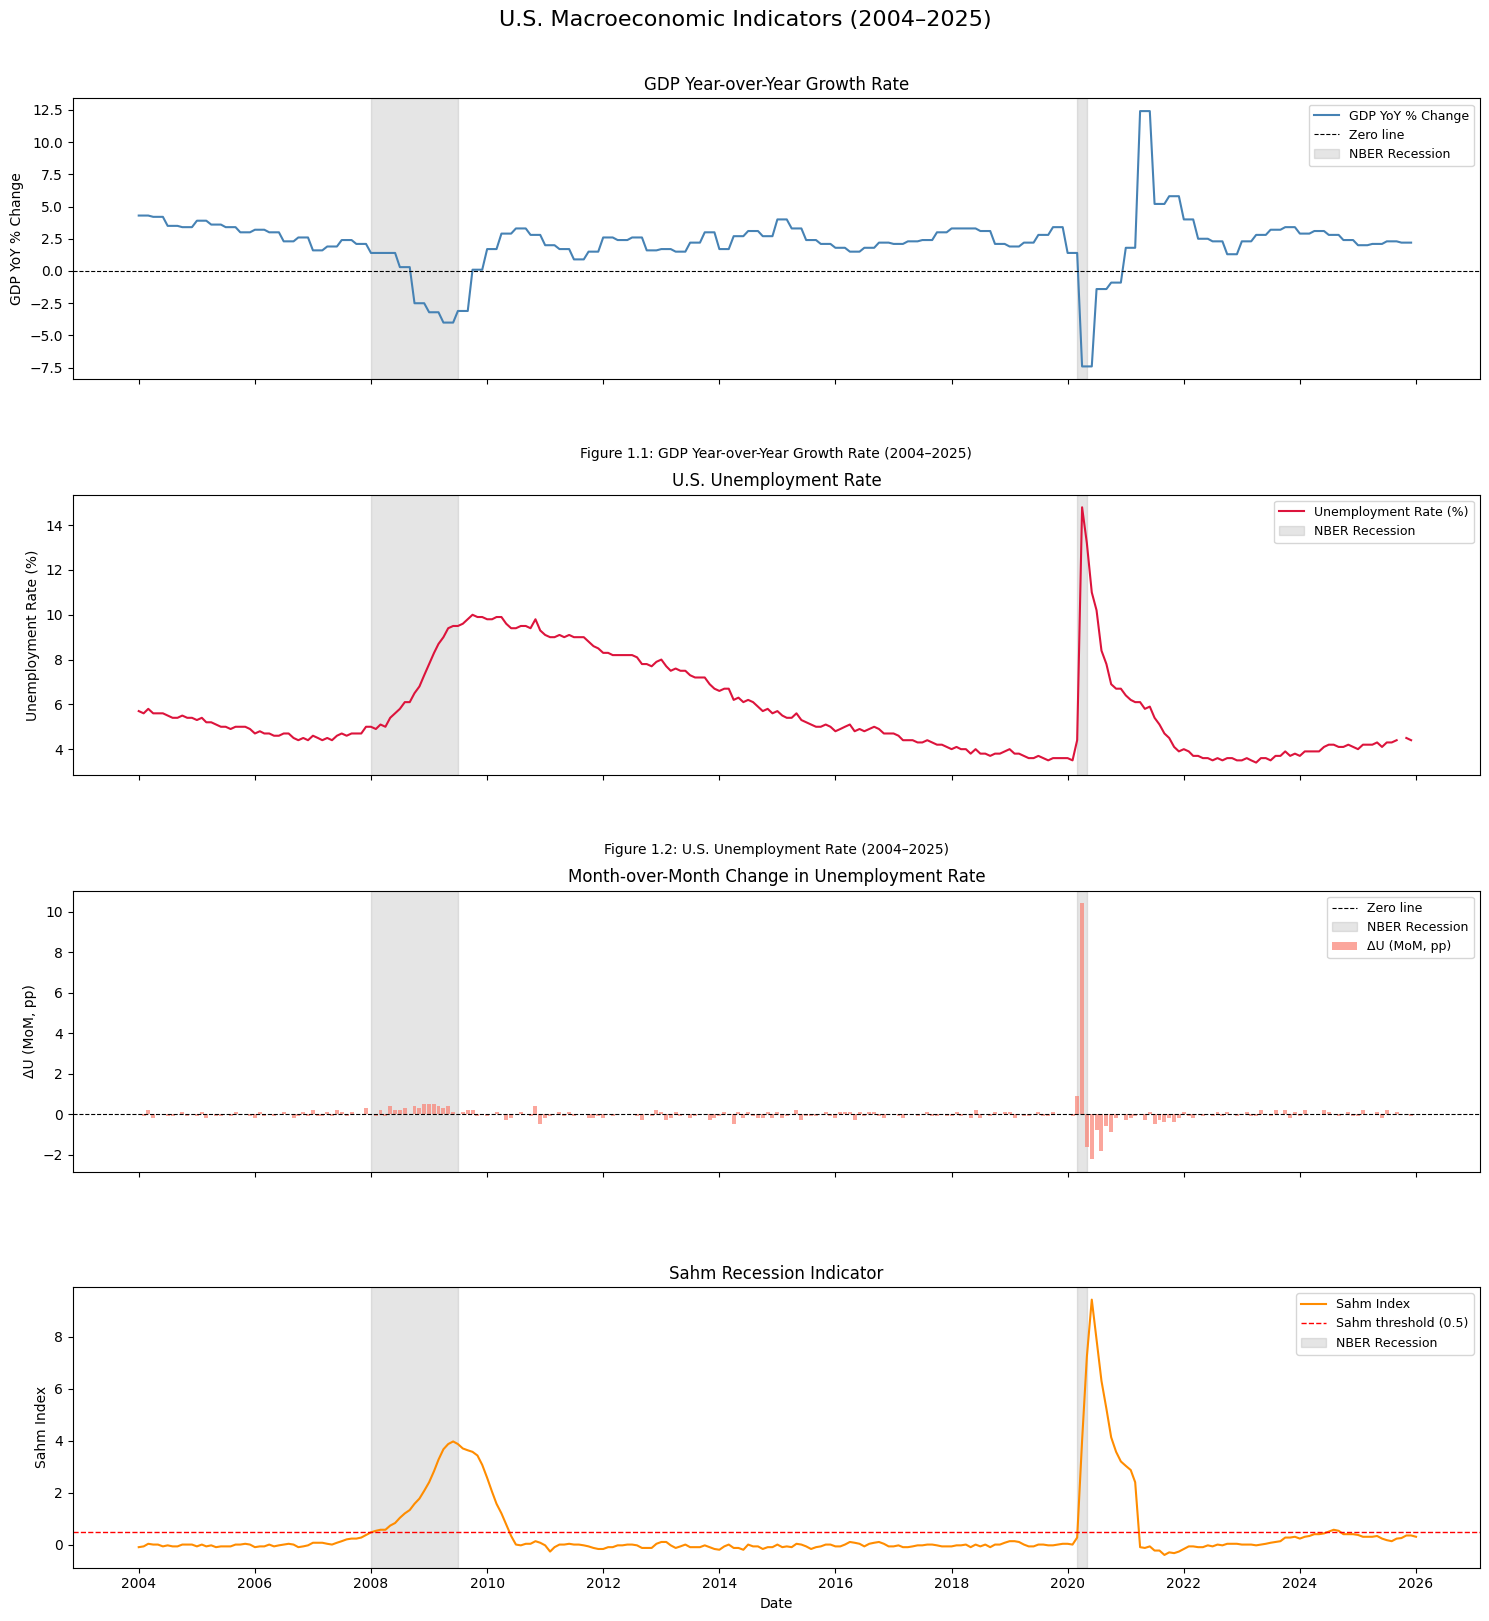

In [21]:
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

# GDP YoY
ax = axes[0]
ax.plot(df["date"], df["gdp_yoy"], color="steelblue", lw=1.5, label="GDP YoY % Change")
ax.axhline(0, color="black", lw=0.8, ls="--", label="Zero line")
shade_recessions(ax)
ax.set_ylabel("GDP YoY % Change")
ax.set_title("GDP Year-over-Year Growth Rate")
ax.legend(loc="upper right", fontsize=9)

ax.text(0.5, -0.28, "Figure 1.1: GDP Year-over-Year Growth Rate (2004–2025)",
        transform=ax.transAxes, ha="center", fontsize=10)

# Unemployment Rate
ax = axes[1]
ax.plot(df["date"], df["unemp_rate"], color="crimson", lw=1.5, label="Unemployment Rate (%)")
shade_recessions(ax)
ax.set_ylabel("Unemployment Rate (%)")
ax.set_title("U.S. Unemployment Rate")
ax.legend(loc="upper right", fontsize=9)

ax.text(0.5, -0.28, "Figure 1.2: U.S. Unemployment Rate (2004–2025)",
        transform=ax.transAxes, ha="center", fontsize=10)

# Change in Unemployment Rate (MoM)
ax = axes[2]
ax.bar(df["date"], df["unemp_rate_mom"], width=25, color="salmon", alpha=0.7, label="ΔU (MoM, pp)")
ax.axhline(0, color="black", lw=0.8, ls="--", label="Zero line")
shade_recessions(ax)
ax.set_ylabel("ΔU (MoM, pp)")
ax.set_title("Month-over-Month Change in Unemployment Rate")
ax.legend(loc="upper right", fontsize=9)

# Sahm Rule Index
ax = axes[3]
ax.plot(df["date"], df["sahm_index"], color="darkorange", lw=1.5, label="Sahm Index")
ax.axhline(0.5, color="red", lw=1, ls="--", label="Sahm threshold (0.5)")
shade_recessions(ax)
ax.set_ylabel("Sahm Index")
ax.set_title("Sahm Recession Indicator")
ax.legend(loc="upper right", fontsize=9)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date")

fig.suptitle("U.S. Macroeconomic Indicators (2004–2025)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

The macro overview confirms that GDP sharply contracts and unemployment spikes during both the 2008 Financial Crisis and the 2020 COVID recession, with the Sahm Index crossing its 0.5 threshold in each event. These clear macroeconomic disruptions provide the baseline against which we test whether Google search behavior shifts in a correlated, or even predictive, manner.

## Google Trends: Average search interest by category over time:

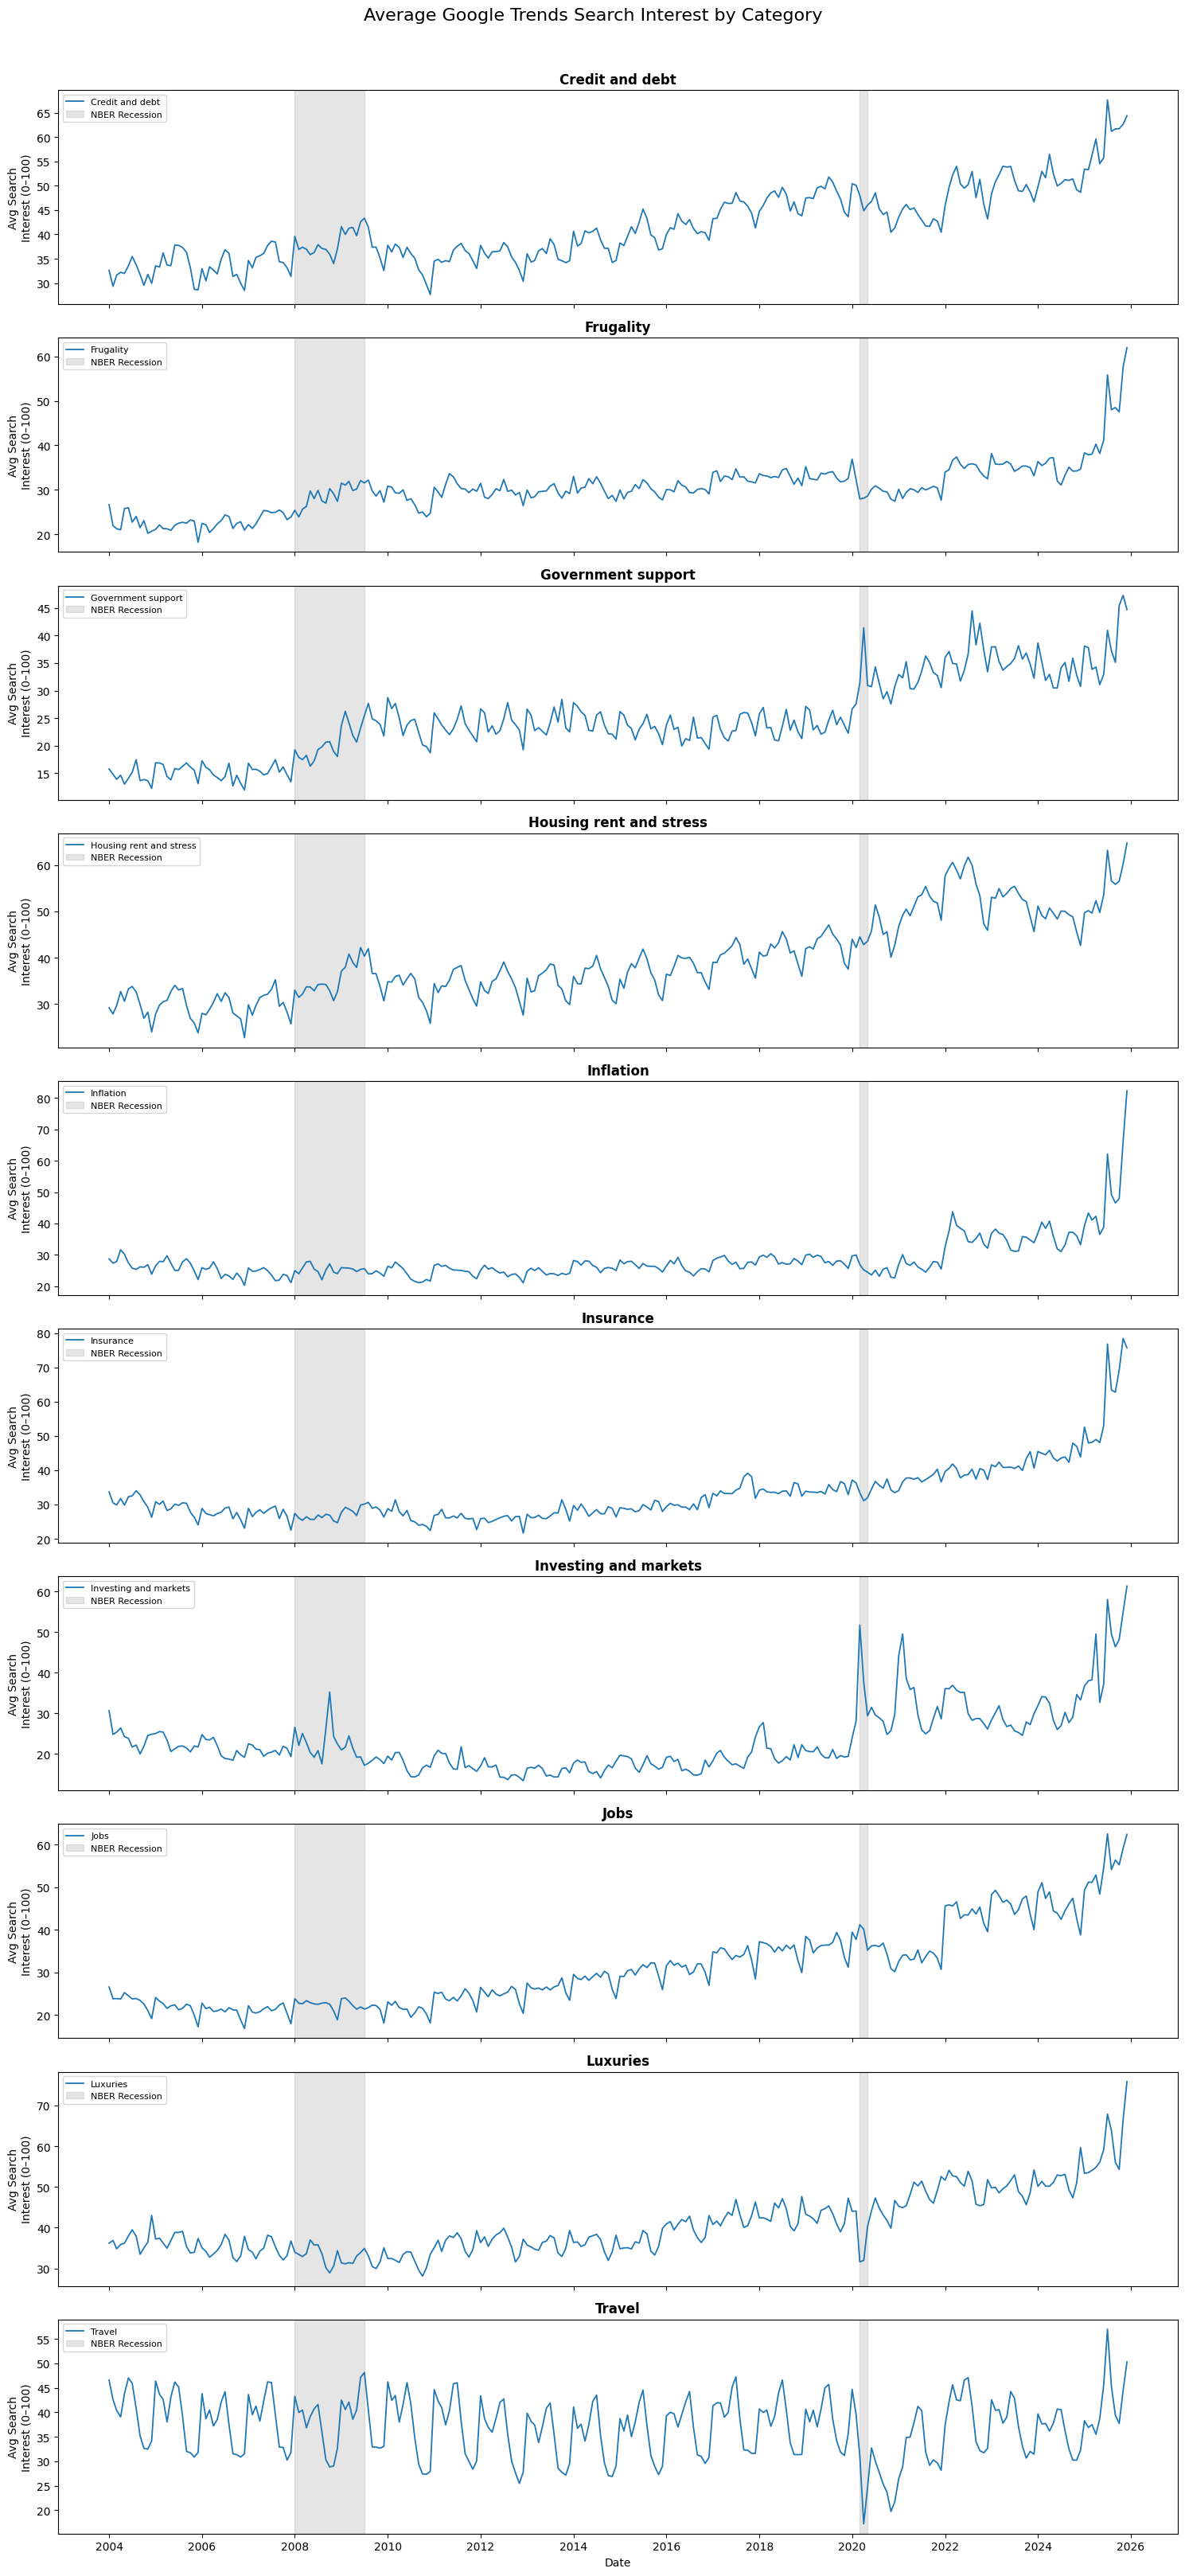

In [22]:
categories = sorted(keywords["category"].unique())
n_cats = len(categories)
fig, axes = plt.subplots(n_cats, 1, figsize=(15, 3.2 * n_cats), sharex=True)

for i, cat in enumerate(categories):
    ax = axes[i]
    col = f"cat_{cat}"
    ax.plot(df["date"], df[col], lw=1.3, label=cat.replace("_", " "))
    shade_recessions(ax)
    ax.set_ylabel("Avg Search\nInterest (0–100)")
    ax.set_title(cat.replace("_", " "), fontsize=12, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[-1].set_xlabel("Date")
fig.suptitle("Average Google Trends Search Interest by Category", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Several search categories, particularly Government Support, Jobs, and Credit & Debt, show visible spikes aligned with recession periods, suggesting that public search behavior shifts meaningfully during economic downturns. Categories like Luxuries and Travel show more muted or opposing patterns, hinting at a divergence between distress-related and discretionary search activity that supports the project hypothesis.

## Dual-axis overlay: Search interest + Unemployment Rate:

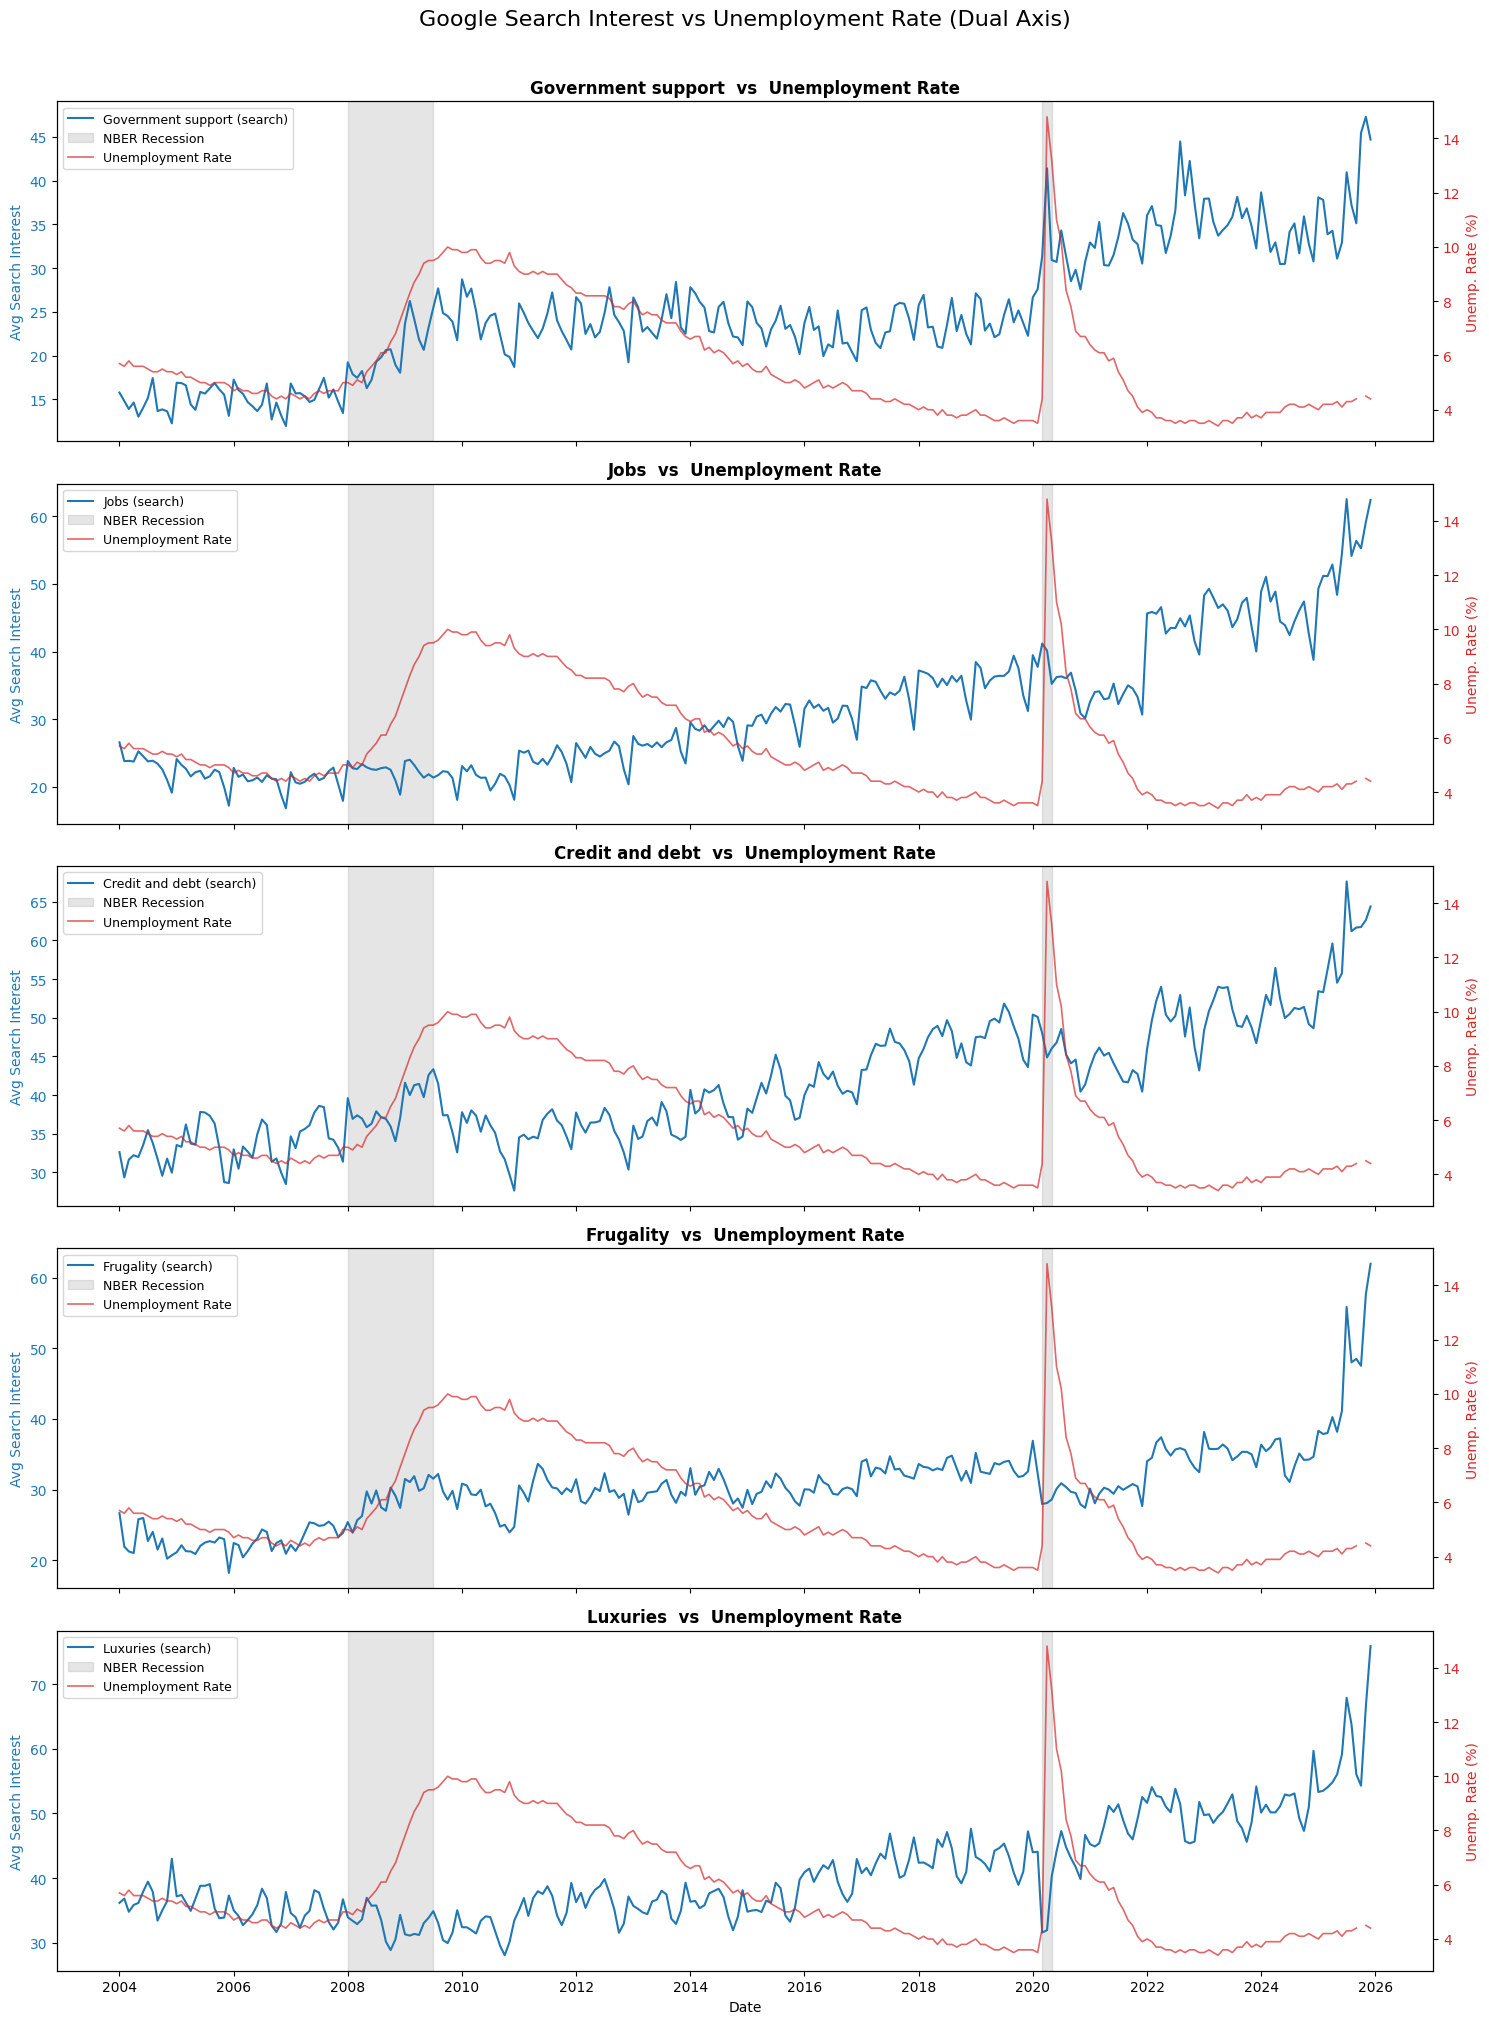

In [23]:
highlight_cats = ["Government_support", "Jobs", "Credit_and_debt", "Frugality", "Luxuries"]

fig, axes = plt.subplots(len(highlight_cats), 1, figsize=(15, 4 * len(highlight_cats)), sharex=True)

for i, cat in enumerate(highlight_cats):
    ax1 = axes[i]
    col = f"cat_{cat}"

    color1 = "tab:blue"
    ax1.plot(df["date"], df[col], color=color1, lw=1.5, label=f"{cat.replace('_', ' ')} (search)")
    ax1.set_ylabel("Avg Search Interest", color=color1)
    ax1.tick_params(axis="y", labelcolor=color1)
    shade_recessions(ax1)

    ax2 = ax1.twinx()
    color2 = "tab:red"
    ax2.plot(df["date"], df["unemp_rate"], color=color2, lw=1.2, alpha=0.7, label="Unemployment Rate")
    ax2.set_ylabel("Unemp. Rate (%)", color=color2)
    ax2.tick_params(axis="y", labelcolor=color2)

    ax1.set_title(f"{cat.replace('_', ' ')}  vs  Unemployment Rate", fontsize=12, fontweight="bold")
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date")
fig.suptitle("Google Search Interest vs Unemployment Rate (Dual Axis)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Overlaying search interest with the unemployment rate reveals that distress-related categories (Government Support, Jobs, Credit & Debt) tend to rise alongside unemployment during recessions, while Luxuries search interest moves inversely. This dual-axis view provides direct visual evidence that Google search behavior tracks, and may even lead, changes in unemployment, supporting the hypothesis that search trends correlate with macroeconomic conditions.

## Top individual keywords time series:

Top 12 most variable keywords: ['Uber_driver', 'DoorDash', 'credit_karma', 'ZipRecruiter', 'Airbnb', 'Upwork', 'Glassdoor', 'Indeed', 'meal_prep', 'Fiverr', 'Lyft_driver', 'last_minute_travel']


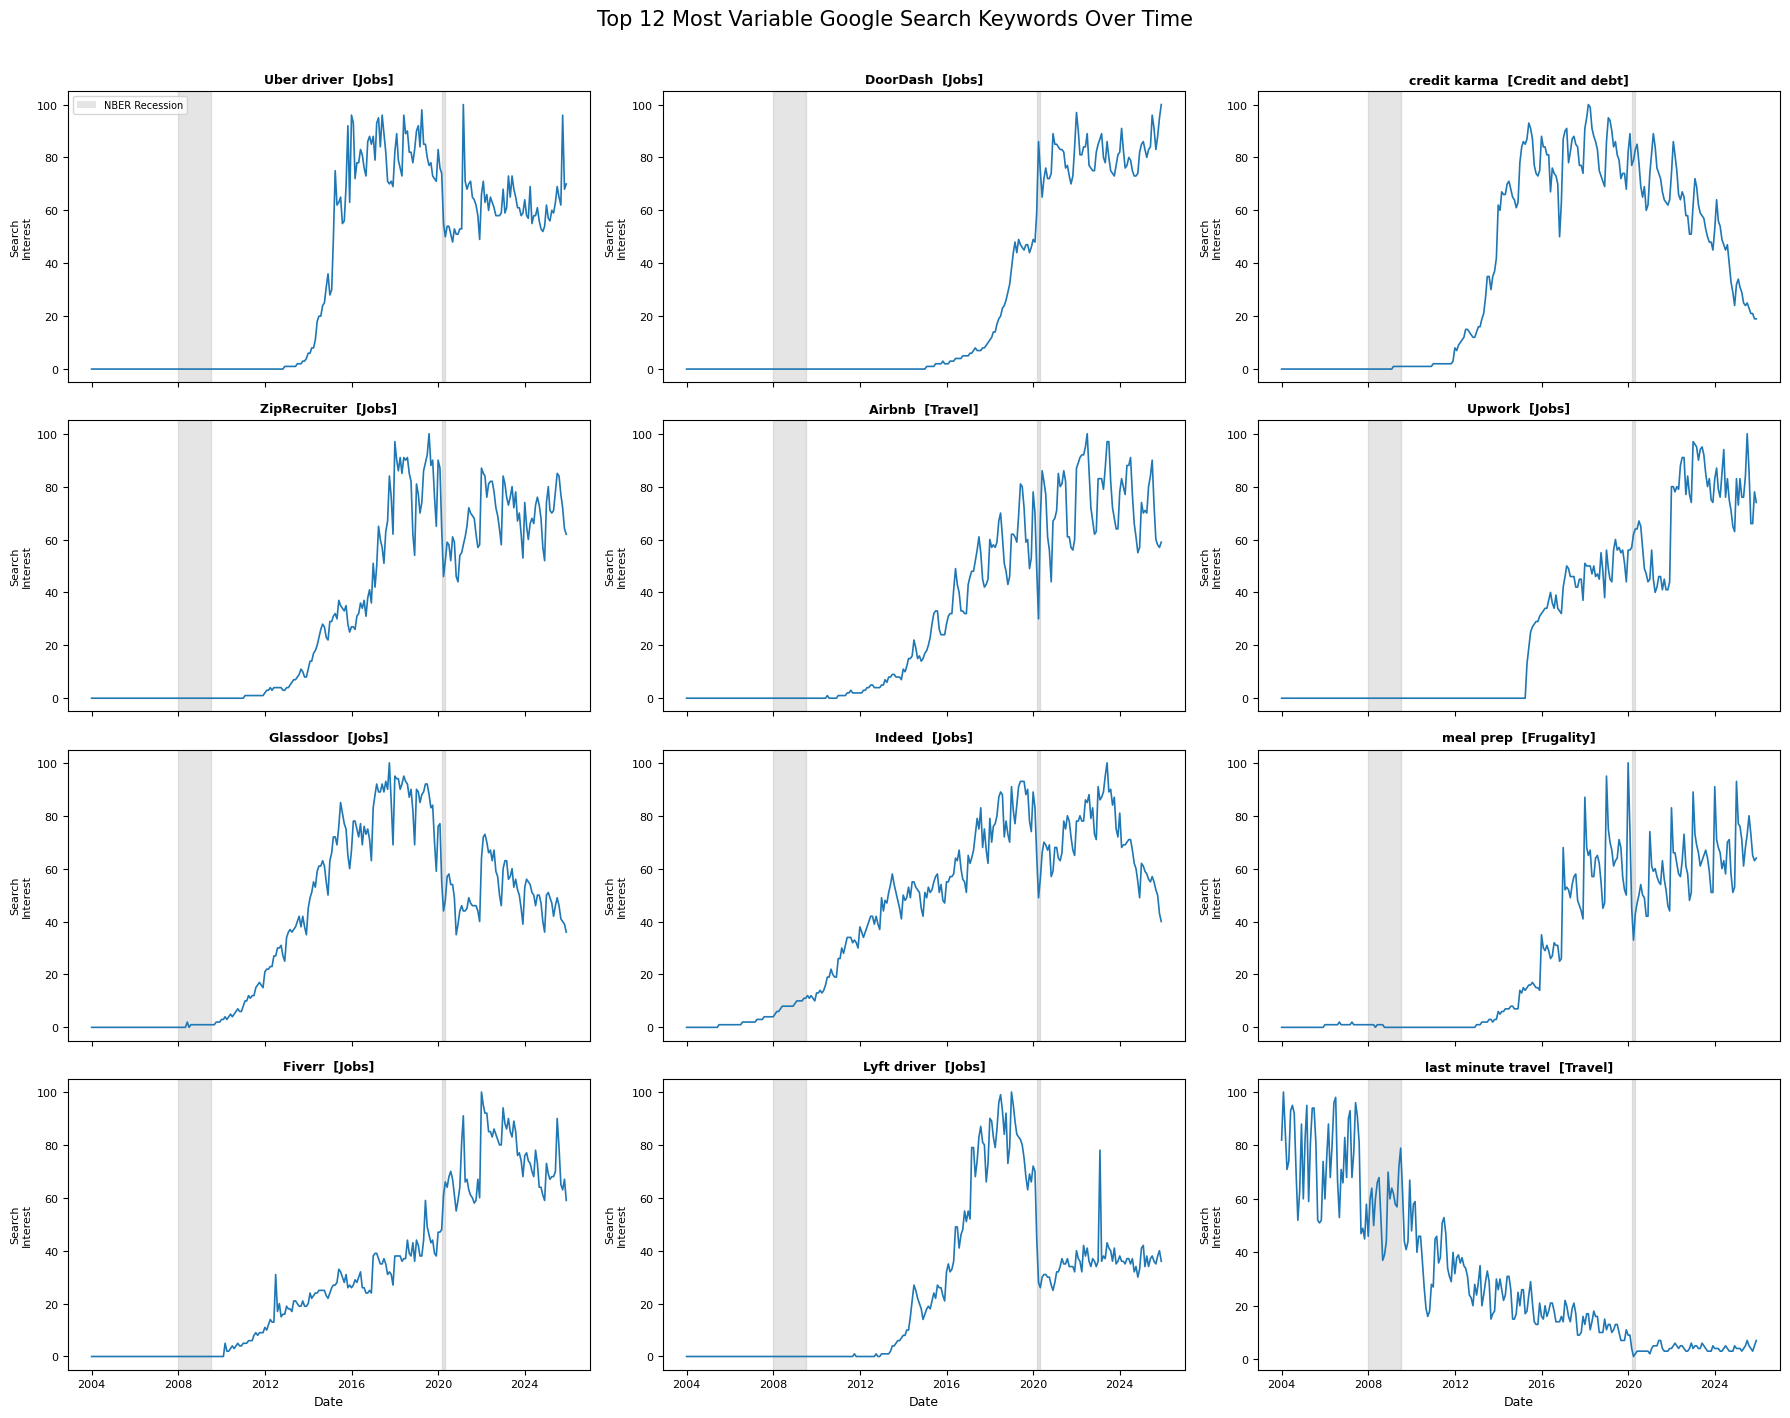

In [24]:
kw_stats = keywords.groupby("keyword")["search_interest"].agg(["mean", "std", "max"])
top_kws = kw_stats.sort_values("std", ascending=False).head(12).index.tolist()
print("Top 12 most variable keywords:", top_kws)

fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharex=True)
for ax, kw in zip(axes.flat, top_kws):
    sub = keywords[keywords["keyword"] == kw]
    cat_label = sub["category"].iloc[0].replace("_", " ")
    ax.plot(sub["date"], sub["search_interest"], lw=1.2,
            label=f"{kw.replace('_', ' ')}")
    shade_recessions(ax, label=False)
    ax.set_title(f"{kw.replace('_', ' ')}  [{cat_label}]", fontsize=9, fontweight="bold")
    ax.set_ylabel("Search\nInterest", fontsize=8)
    ax.tick_params(labelsize=8)

for ax in axes[-1]:
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("Date", fontsize=9)

# Add a shared recession legend on the first subplot
from matplotlib.patches import Patch
axes[0, 0].legend(handles=[Patch(facecolor="grey", alpha=0.2, label="NBER Recession")],
                  loc="upper left", fontsize=7)

fig.suptitle("Top 12 Most Variable Google Search Keywords Over Time", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

The most variable keywords, including DoorDash, Uber Driver, ZipRecruiter, and Indeed, primarily belong to the Jobs category, reflecting the gig economy's responsiveness to labor market conditions. These high-volatility keywords show pronounced spikes during and after recessions, suggesting that individual search terms related to alternative employment are particularly sensitive to economic downturns.

# Summary Statistics:

## Per-keyword summary statistics:

In [25]:
kw_summary = (keywords.groupby(["keyword", "category"])["search_interest"]
              .agg(mean="mean", std="std", min="min", max="max",
                   skew=lambda x: x.skew())
              .reset_index()
              .sort_values("std", ascending=False))

print("Top 20 keywords by standard deviation:")
kw_summary.head(20).round({"mean": 1, "std": 1, "skew": 2})

Top 20 keywords by standard deviation:


,keyword,category,mean,std,min,max,skew
63,Uber_driver,Jobs,35.6,35.5,0,100,0.20
18,DoorDash,Jobs,25.3,35.2,0,100,0.89
158,credit_karma,Credit_and_debt,38.9,35.2,0,100,0.12
71,ZipRecruiter,Jobs,33.4,33.7,0,100,0.36
5,Airbnb,Travel,31.8,32.8,0,100,0.46
65,Upwork,Jobs,28.4,32.6,0,100,0.60
29,Glassdoor,Jobs,38.8,31.9,0,100,0.13
35,Indeed,Jobs,44.4,30.3,0,100,-0.17
324,meal_prep,Frugality,27.7,29.9,0,100,0.48
25,Fiverr,Jobs,30.7,29.6,0,100,0.61


Keywords with the highest standard deviations tend to be gig-economy and job-search terms, indicating these are the most responsive to economic cycles. The positive skewness in many distress-related keywords confirms that they exhibit sharp upward spikes during recessions rather than gradual changes, consistent with sudden shifts in public economic anxiety.

## Recession vs Expansion: mean search interest comparison:

In [26]:
kw_rec = keywords.merge(df[["date", "recession"]], on="date", how="left")

rec_vs_exp = (kw_rec.groupby(["keyword", "category", "recession"])["search_interest"]
              .mean().unstack("recession")
              .rename(columns={0: "expansion_mean", 1: "recession_mean"}))
rec_vs_exp["recession_uplift"] = rec_vs_exp["recession_mean"] - rec_vs_exp["expansion_mean"]
rec_vs_exp["pct_uplift"] = (rec_vs_exp["recession_uplift"] / rec_vs_exp["expansion_mean"].replace(0, np.nan)) * 100
rec_vs_exp = rec_vs_exp.sort_values("recession_uplift", ascending=False).reset_index()

print("Keywords with LARGEST recession uplift (distress signals):")
display(rec_vs_exp.head(20).round(
    {"expansion_mean": 1, "recession_mean": 1, "recession_uplift": 1, "pct_uplift": 0}
))

print("\nKeywords with LARGEST recession DROP (luxury/discretionary signals):")
display(rec_vs_exp.tail(20).round(
    {"expansion_mean": 1, "recession_mean": 1, "recession_uplift": 1, "pct_uplift": 0}
))

Keywords with LARGEST recession uplift (distress signals):


recession,keyword,category,expansion_mean,recession_mean,recession_uplift,pct_uplift
0,foreclosure,Housing_rent_and_stress,31.0,75.0,44.0,142.0
1,debt_settlement,Credit_and_debt,25.6,60.9,35.3,138.0
2,credit_counseling,Credit_and_debt,30.6,65.8,35.2,115.0
3,telecommute,Jobs,41.2,72.1,30.9,75.0
4,wedding_locations,Travel,32.1,62.0,29.8,93.0
5,oil_prices,Investing_and_markets,17.9,46.4,28.5,159.0
6,energy_saving_tips,Frugality,16.5,44.2,27.8,169.0
7,grocery_coupons,Frugality,12.4,39.2,26.8,215.0
8,bankruptcy,Credit_and_debt,40.7,67.5,26.8,66.0
9,eco_tourism,Travel,28.4,54.1,25.7,90.0



Keywords with LARGEST recession DROP (luxury/discretionary signals):


recession,keyword,category,expansion_mean,recession_mean,recession_uplift,pct_uplift
479,Upwork,Jobs,30.2,6.0,-24.3,-80.0
480,prequalified_credit_card,Credit_and_debt,28.7,4.1,-24.6,-86.0
481,water_bill_assistance,Housing_rent_and_stress,28.1,3.2,-24.9,-89.0
482,SSDI_application,Government_support,36.2,11.2,-24.9,-69.0
483,meal_prep,Frugality,29.6,4.3,-25.3,-85.0
484,VRBO,Travel,48.3,22.6,-25.7,-53.0
485,promo_code,Frugality,48.1,21.8,-26.3,-55.0
486,LinkedIn_Jobs,Jobs,35.2,8.2,-27.0,-77.0
487,title_loan,Credit_and_debt,57.9,30.6,-27.3,-47.0
488,Fiverr,Jobs,32.8,5.4,-27.3,-83.0


## Bar chart: recession uplift by category:

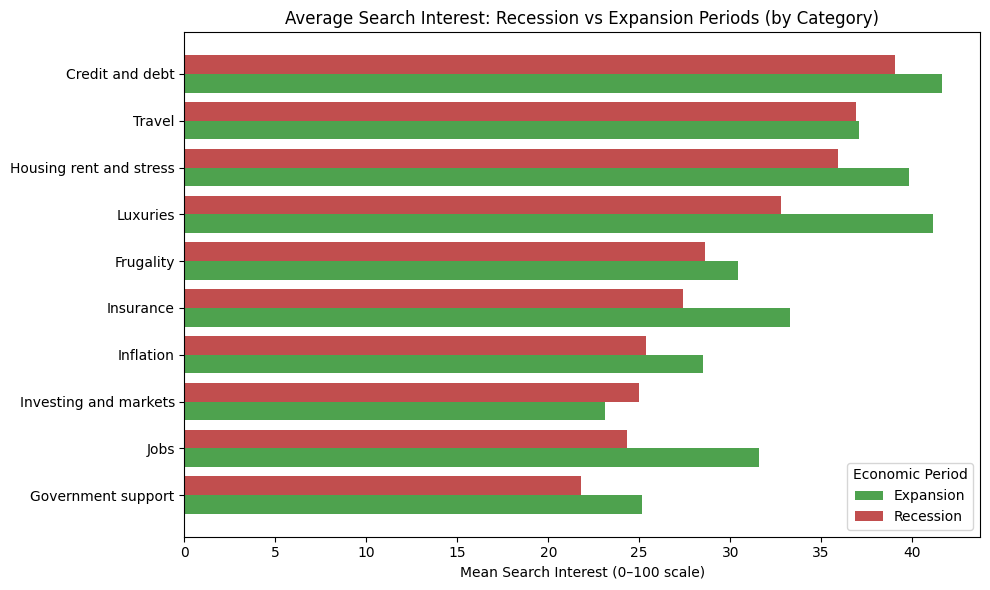

In [27]:
cat_rec = rec_vs_exp.groupby("category")[["expansion_mean", "recession_mean"]].mean()
cat_rec = cat_rec.sort_values("recession_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y = range(len(cat_rec))
ax.barh(y, cat_rec["expansion_mean"], height=0.4, label="Expansion", color="forestgreen", alpha=0.8)
ax.barh([yi + 0.4 for yi in y], cat_rec["recession_mean"], height=0.4, label="Recession", color="firebrick", alpha=0.8)
ax.set_yticks([yi + 0.2 for yi in y])
ax.set_yticklabels([c.replace("_", " ") for c in cat_rec.index])
ax.set_xlabel("Mean Search Interest (0–100 scale)")
ax.set_title("Average Search Interest: Recession vs Expansion Periods (by Category)")
ax.legend(title="Economic Period", fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

Keywords related to government assistance (food stamps, unemployment benefits, stimulus check) show the largest recession uplift, while luxury and discretionary terms decline during downturns. This divergence between distress and luxury search behavior directly supports the hypothesis that Google search trends reflect underlying economic conditions and can distinguish between recession and expansion periods.

# Correlation Matrix:


## Correlation matrix: category search interest vs macro variables

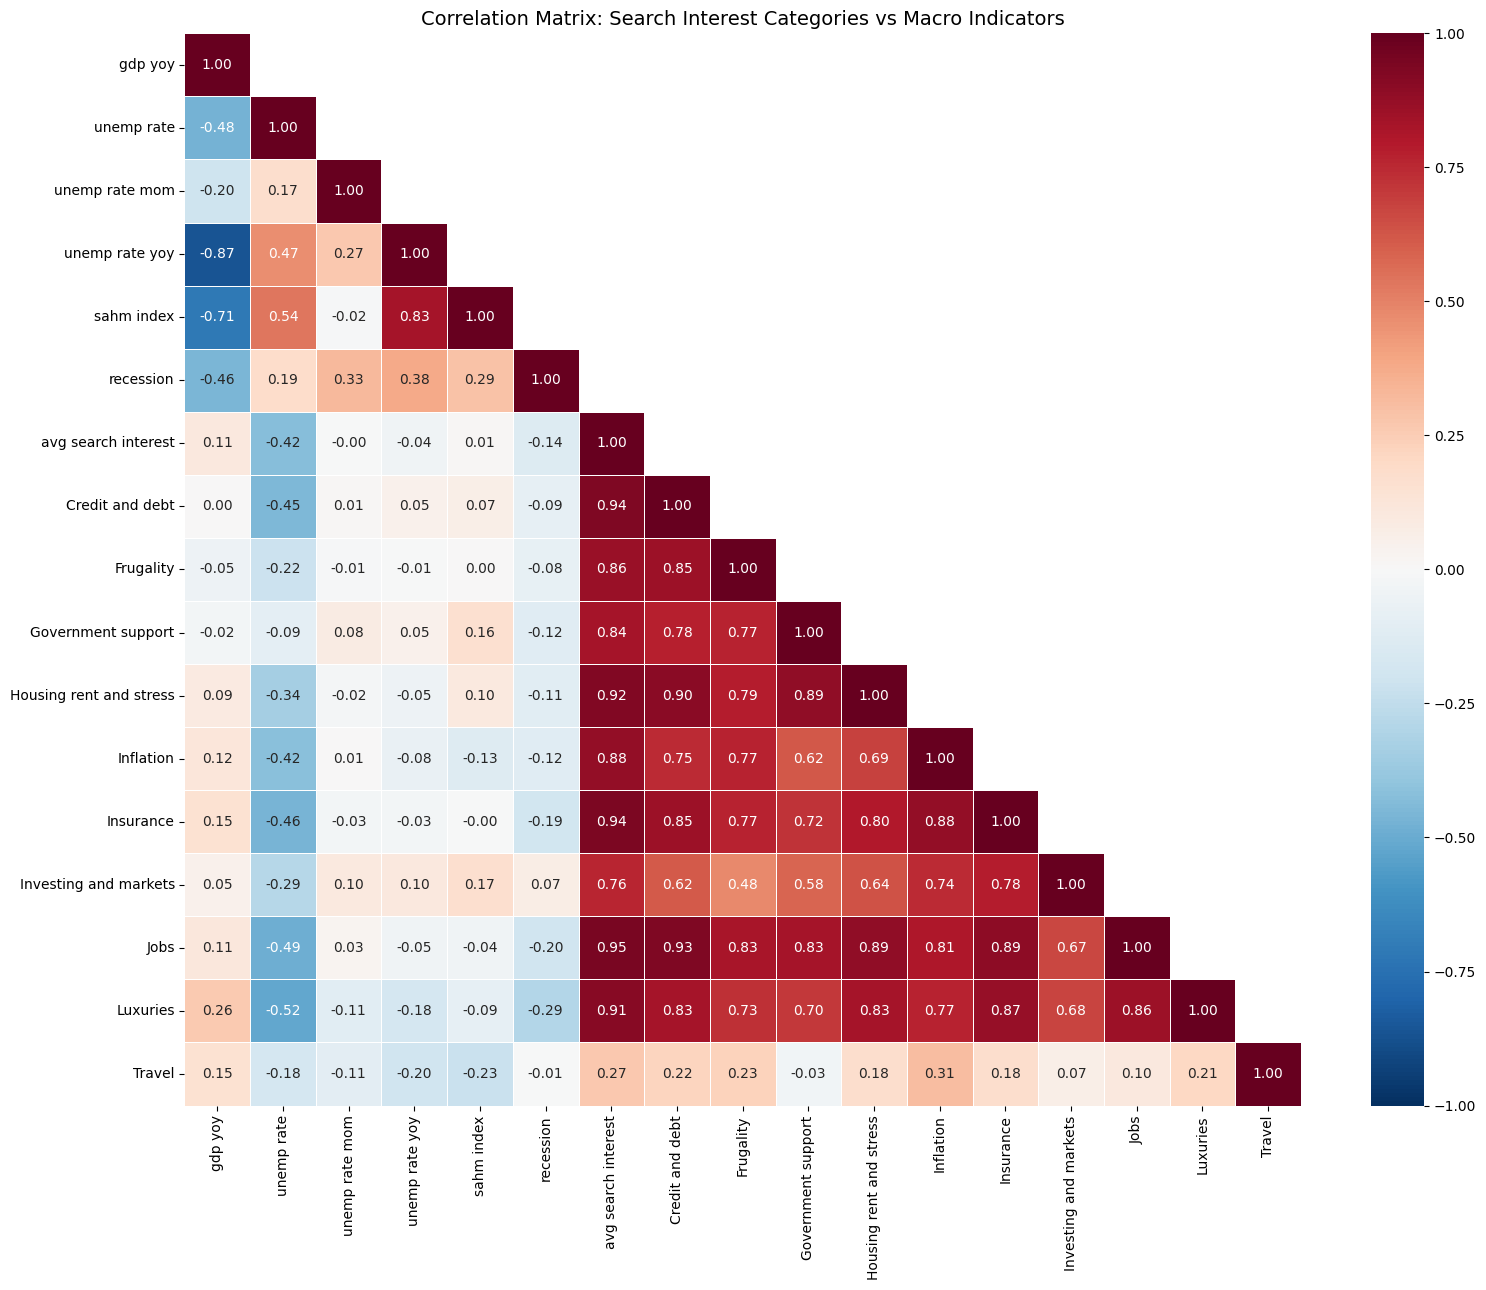

In [28]:
corr_cols = (["gdp_yoy", "unemp_rate", "unemp_rate_mom", "unemp_rate_yoy",
              "sahm_index", "recession", "avg_search_interest"]
             + [f"cat_{c}" for c in categories])

corr_df = df[corr_cols].dropna()
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=[c.replace("cat_", "").replace("_", " ") for c in corr_mat.columns],
            yticklabels=[c.replace("cat_", "").replace("_", " ") for c in corr_mat.index],
            ax=ax)
ax.set_title("Correlation Matrix: Search Interest Categories vs Macro Indicators", fontsize=14)
plt.tight_layout()
plt.show()

The correlation matrix reveals that most search categories are negatively correlated with the unemployment rate at the raw level, partly driven by opposing long-run trends: growing internet adoption vs. declining structural unemployment. However, categories like Investing & Markets and Government Support show meaningful correlations with the Sahm Index and recession flag, indicating these categories capture cyclical economic distress signals beyond the secular trend.

## Top individual keyword correlations with macro vars

In [29]:
# Merge each keyword's search interest with macro data
macro_subset = df[["date", "gdp_yoy", "unemp_rate", "unemp_rate_mom", "recession"]].copy()
macro_subset.rename(columns={"recession": "recession_flag"}, inplace=True)

kw_wide_macro = keywords_wide.merge(
    macro_subset, left_index=True, right_on="date", how="inner"
).set_index("date")

macro_targets = ["gdp_yoy", "unemp_rate", "unemp_rate_mom", "recession_flag"]
all_kw_cols = [c for c in kw_wide_macro.columns if c not in macro_targets]

corr_with_macro = pd.DataFrame(index=all_kw_cols)
for target in macro_targets:
    corr_with_macro[target] = kw_wide_macro[all_kw_cols].corrwith(kw_wide_macro[target])

corr_with_macro.rename(columns={"recession_flag": "recession"}, inplace=True)

# Show top 15 keywords most positively correlated with recession
print("Top 15 keywords most POSITIVELY correlated with recession:")
display(corr_with_macro.sort_values("recession", ascending=False).head(15).round(3))

print("\nTop 15 keywords most NEGATIVELY correlated with recession (drop during downturns):")
display(corr_with_macro.sort_values("recession", ascending=True).head(15).round(3))

Top 15 keywords most POSITIVELY correlated with recession:


,gdp_yoy,unemp_rate,unemp_rate_mom,recession
mortgage_rates,-0.391,0.190,0.198,0.600
foreclosure,-0.394,0.602,0.054,0.590
rebate,-0.098,0.039,0.044,0.527
oil_prices,-0.312,0.071,0.376,0.518
debt_settlement,-0.425,0.514,0.068,0.500
commodity_prices,-0.158,0.311,0.129,0.493
recession,-0.341,-0.011,0.182,0.478
short_selling,-0.219,0.152,0.066,0.465
grocery_coupons,-0.321,0.551,0.051,0.454
money_saving_tips,-0.272,0.411,0.054,0.443



Top 15 keywords most NEGATIVELY correlated with recession (drop during downturns):


,gdp_yoy,unemp_rate,unemp_rate_mom,recession
credit_card_application,0.203,-0.367,-0.080,-0.389
engagement_ring,0.175,-0.051,-0.116,-0.374
wedding_ring,0.189,-0.352,-0.115,-0.360
diamond_ring,0.217,-0.449,-0.122,-0.353
painting_for_sale,0.050,-0.126,-0.039,-0.338
bracelet,0.175,-0.285,-0.077,-0.337
TaskRabbit,0.172,-0.380,-0.062,-0.333
Louis_Vuitton,0.175,-0.187,-0.086,-0.315
title_loan,0.131,-0.382,-0.073,-0.312
LinkedIn_Jobs,0.117,-0.382,-0.041,-0.306


At the individual keyword level, terms most positively correlated with recessions are distress-related (unemployment benefits, food stamps, foreclosure), while negatively correlated keywords are luxury or discretionary terms. This granular analysis confirms that specific Google search terms serve as reliable indicators of recessionary conditions, reinforcing the project's central finding.

# Scatterplots with Regression Lines:

## Category search interest vs GDP growth:

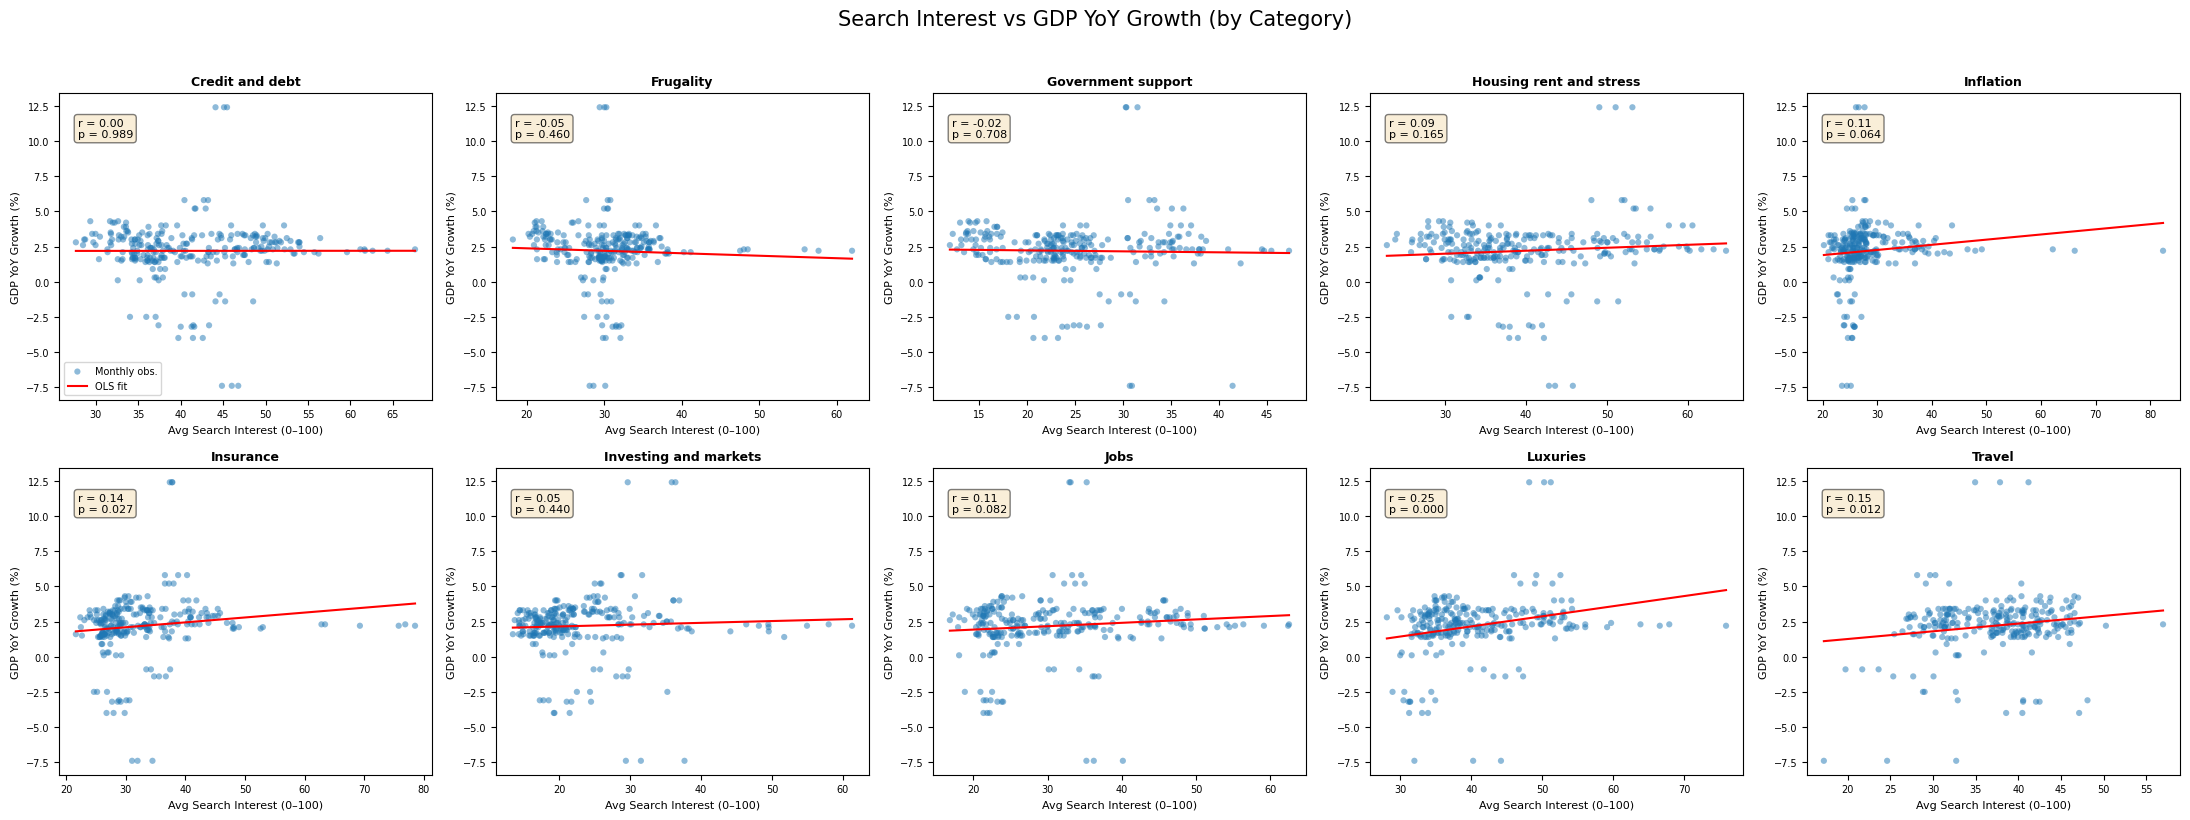

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, cat in zip(axes.flat, categories):
    col = f"cat_{cat}"
    tmp = df[[col, "gdp_yoy"]].dropna()
    ax.scatter(tmp[col], tmp["gdp_yoy"], alpha=0.5, s=20, edgecolors="none",
               label="Monthly obs.")

    # Regression line
    if tmp[col].std() > 0:
        slope, intercept, r, p, se = stats.linregress(tmp[col], tmp["gdp_yoy"])
        x_line = np.linspace(tmp[col].min(), tmp[col].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, "r-", lw=1.5,
                label="OLS fit")
        ax.text(0.05, 0.92, f"r = {r:.2f}\np = {p:.3f}",
                transform=ax.transAxes, fontsize=8, verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    ax.set_title(cat.replace("_", " "), fontsize=9, fontweight="bold")
    ax.set_xlabel("Avg Search Interest (0–100)", fontsize=8)
    ax.set_ylabel("GDP YoY Growth (%)", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7, loc="lower left")

fig.suptitle("Search Interest vs GDP YoY Growth (by Category)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Category search interest vs MoM Unemployment:

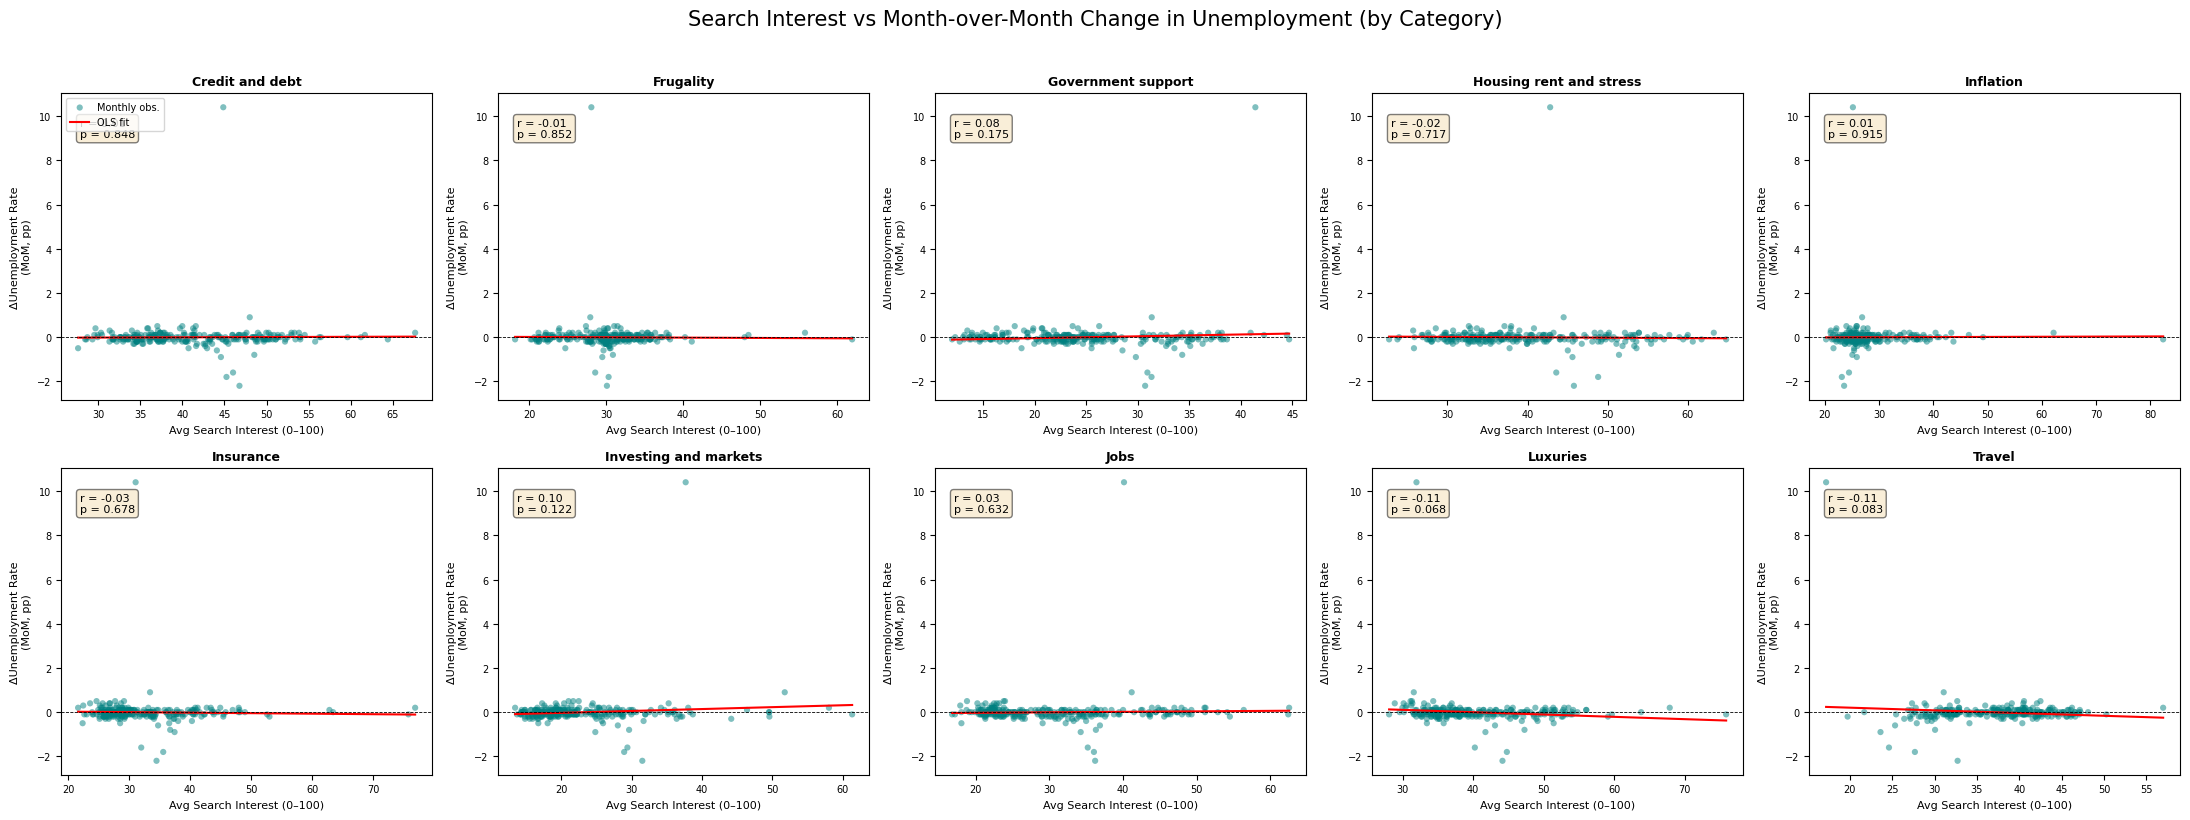

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, cat in zip(axes.flat, categories):
    col = f"cat_{cat}"
    tmp = df[[col, "unemp_rate_mom"]].dropna()
    ax.scatter(tmp[col], tmp["unemp_rate_mom"], alpha=0.5, s=20, edgecolors="none",
               color="teal", label="Monthly obs.")
    if tmp[col].std() > 0:
        slope, intercept, r, p, se = stats.linregress(tmp[col], tmp["unemp_rate_mom"])
        x_line = np.linspace(tmp[col].min(), tmp[col].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, "r-", lw=1.5, label="OLS fit")
        ax.text(0.05, 0.92, f"r = {r:.2f}\np = {p:.3f}",
                transform=ax.transAxes, fontsize=8, verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    ax.axhline(0, color="black", lw=0.6, ls="--")
    ax.set_title(cat.replace("_", " "), fontsize=9, fontweight="bold")
    ax.set_xlabel("Avg Search Interest (0–100)", fontsize=8)
    ax.set_ylabel("ΔUnemployment Rate\n(MoM, pp)", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7, loc="upper left")

fig.suptitle("Search Interest vs Month-over-Month Change in Unemployment (by Category)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

The scatterplots show weak to moderate linear relationships between search interest and GDP growth or MoM Unemployment at the contemporaneous level, with Luxuries showing the strongest positive association with GDP growth. The generally weak instantaneous correlations suggest that the relationship between search behavior and macroeconomic outcomes may be lagged rather than simultaneous, motivating the lag analysis that follows.

# Lag Analysis: do searches predict future unemployment changes?

## Lag correlation: S_t correlated with ΔU_{t+lag}:

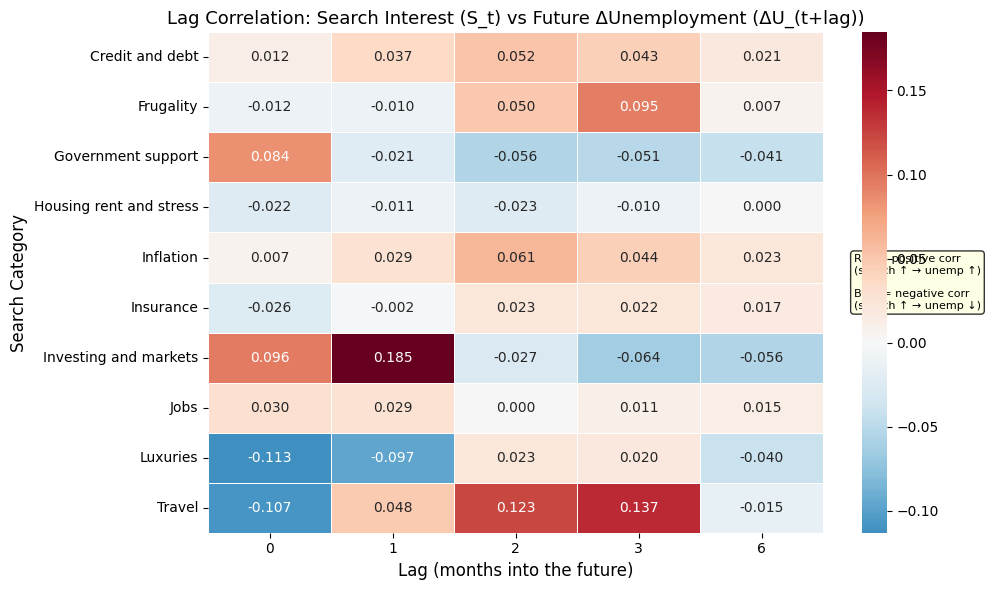

Interpretation: positive values mean higher search interest today correlates with rising unemployment in the future; possible leading indicator.


In [32]:
lags = [0, 1, 2, 3, 6]
lag_results = []

for cat in categories:
    col = f"cat_{cat}"
    for lag in lags:
        tmp = df[["date", col, "unemp_rate_mom"]].dropna().copy()
        tmp["unemp_future"] = tmp["unemp_rate_mom"].shift(-lag)
        valid = tmp.dropna()
        if len(valid) > 10:
            r, p = stats.pearsonr(valid[col], valid["unemp_future"])
            lag_results.append({
                "category": cat, "lag_months": lag,
                "correlation": r, "p_value": p, "n": len(valid)
            })

lag_df = pd.DataFrame(lag_results)
lag_pivot = lag_df.pivot(index="category", columns="lag_months", values="correlation")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(lag_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax,
            yticklabels=[c.replace("_", " ") for c in lag_pivot.index])
ax.set_xlabel("Lag (months into the future)", fontsize=12)
ax.set_ylabel("Search Category", fontsize=12)
ax.set_title("Lag Correlation: Search Interest (S_t) vs Future ΔUnemployment (ΔU_(t+lag))", fontsize=13)
ax.text(1.05, 0.5, "Red = positive corr\n(search ↑ → unemp ↑)\n\nBlue = negative corr\n(search ↑ → unemp ↓)",
        transform=ax.transAxes, fontsize=8, va="center",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
plt.tight_layout()
plt.show()

print("Interpretation: positive values mean higher search interest today correlates with rising unemployment in the future; possible leading indicator.")

## Same lag analysis but for GDP growth:

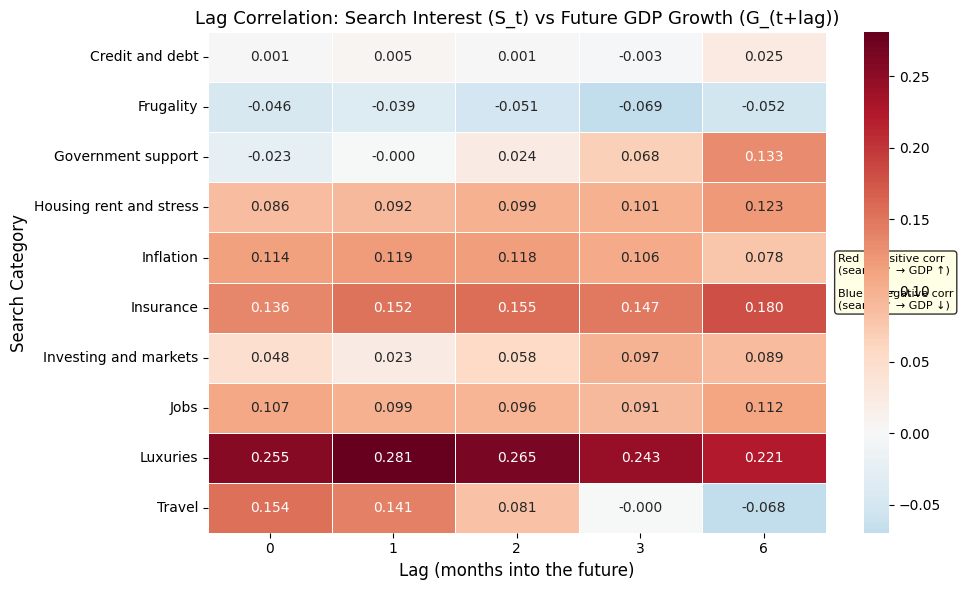

Interpretation: negative values mean higher search interest today correlates with falling GDP in the future.


In [33]:
lag_gdp_results = []

for cat in categories:
    col = f"cat_{cat}"
    for lag in lags:
        tmp = df[["date", col, "gdp_yoy"]].dropna().copy()
        tmp["gdp_future"] = tmp["gdp_yoy"].shift(-lag)
        valid = tmp.dropna()
        if len(valid) > 10:
            r, p = stats.pearsonr(valid[col], valid["gdp_future"])
            lag_gdp_results.append({
                "category": cat, "lag_months": lag,
                "correlation": r, "p_value": p, "n": len(valid)
            })

lag_gdp_df = pd.DataFrame(lag_gdp_results)
lag_gdp_pivot = lag_gdp_df.pivot(index="category", columns="lag_months", values="correlation")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(lag_gdp_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax,
            yticklabels=[c.replace("_", " ") for c in lag_gdp_pivot.index])
ax.set_xlabel("Lag (months into the future)", fontsize=12)
ax.set_ylabel("Search Category", fontsize=12)
ax.set_title("Lag Correlation: Search Interest (S_t) vs Future GDP Growth (G_(t+lag))", fontsize=13)
ax.text(1.02, 0.5, "Red = positive corr\n(search ↑ → GDP ↑)\n\nBlue = negative corr\n(search ↑ → GDP ↓)",
        transform=ax.transAxes, fontsize=8, va="center",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
plt.tight_layout()
plt.show()

print("Interpretation: negative values mean higher search interest today correlates with falling GDP in the future.")

## Top individual keywords as leading indicators (lag=3):

In [34]:
lag_kw_results = []
for kw in keywords["keyword"].unique():
    sub = keywords[keywords["keyword"] == kw][["date", "search_interest"]].set_index("date")
    merged = sub.join(df.set_index("date")[["unemp_rate_mom", "gdp_yoy"]], how="inner")
    for lag in [1, 3, 6]:
        merged[f"unemp_future_{lag}"] = merged["unemp_rate_mom"].shift(-lag)
        valid = merged[["search_interest", f"unemp_future_{lag}"]].dropna()
        if len(valid) > 20 and valid["search_interest"].std() > 0:
            r, p = stats.pearsonr(valid["search_interest"], valid[f"unemp_future_{lag}"])
            lag_kw_results.append({"keyword": kw, "lag": lag, "corr_unemp": r, "p_unemp": p})

lag_kw_df = pd.DataFrame(lag_kw_results)

# Best leading indicators at 3 month lag
best_lead_3 = lag_kw_df[lag_kw_df["lag"] == 3].sort_values("corr_unemp", ascending=False)
print("Top 15 keywords as LEADING indicators (3 month lag, S_t -> ΔU_(t+3):")
display(best_lead_3.head(15).round({"corr_unemp": 3, "p_unemp": 4}))

Top 15 keywords as LEADING indicators (3 month lag, S_t -> ΔU_(t+3):


,keyword,lag,corr_unemp,p_unemp
1324,Disney_tickets,3,0.213,0.0006
247,minimalism_tips,3,0.212,0.0006
157,budget_planner,3,0.210,0.0007
169,cash_envelope_system,3,0.180,0.0037
1327,Mediterranean_cruise,3,0.160,0.0100
241,meal_planning,3,0.144,0.0203
1456,weekend_getaway,3,0.137,0.0279
1387,flight_deals,3,0.133,0.0323
1291,spa_treatment,3,0.133,0.0330
1315,Caribbean_cruise,3,0.132,0.0332


The lag analysis reveals that several search categories show stronger correlations with future MoM Unemployment (1-6 months ahead) than with contemporaneous values, suggesting Google search trends can serve as leading indicators of labor market deterioration. Categories like Government Support and Investing & Markets show increasing predictive power at 3-6 month lags, providing the strongest evidence that search behavior anticipates, rather than merely reacts to, economic downturns. This is the most compelling finding for the project hypothesis.